# Task 3: Model Validation, Overfitting Control & Hyperparameter Tuning
**Dataset:** California Housing Dataset (scikit-learn)  
**Goal:** Detect overfitting, apply cross-validation, tune hyperparameters using GridSearchCV

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

print("Shape:", df.shape)
df.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling applied using StandardScaler")

Feature scaling applied using StandardScaler


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 16512
Testing samples:  4128


## Step 1: Detect Overfitting
Comparing training vs testing RMSE to detect if the model is overfitting.  
A large gap between train and test RMSE = overfitting.

In [6]:
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

train_pred = tree.predict(X_train)
test_pred  = tree.predict(X_test)

train_rmse = mean_squared_error(y_train, train_pred) ** 0.5
test_rmse  = mean_squared_error(y_test, test_pred) ** 0.5

print(f"Decision Tree (No Depth Limit)")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test  RMSE: {test_rmse:.4f}")
print(f"Gap:        {test_rmse - train_rmse:.4f}")

if test_rmse - train_rmse > 0.2:
    print("⚠️  Overfitting detected — large gap between train and test RMSE")
else:
    print("✅  No significant overfitting")

Decision Tree (No Depth Limit)
Train RMSE: 0.0000
Test  RMSE: 0.7022
Gap:        0.7022
⚠️  Overfitting detected — large gap between train and test RMSE


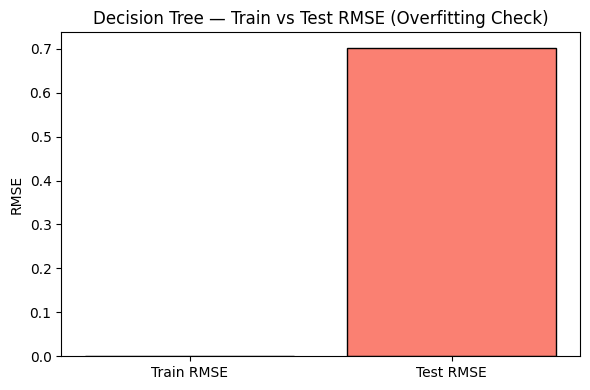

In [7]:
labels = ['Train RMSE', 'Test RMSE']
values = [train_rmse, test_rmse]

plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Decision Tree — Train vs Test RMSE (Overfitting Check)')
plt.ylabel('RMSE')
plt.tight_layout()
plt.savefig('overfitting_check.png')
plt.show()

## Step 2: Cross-Validation
Using 5-Fold Cross-Validation for reliable performance estimation.  
This reduces dependency on a single train-test split.

In [8]:
cv_scores = cross_val_score(
    tree, X_scaled, y,
    scoring="neg_root_mean_squared_error",
    cv=5
)

cv_rmse = -cv_scores.mean()
cv_std  = cv_scores.std()

print(f"Cross-Validation RMSE (5-Fold): {cv_rmse:.4f}")
print(f"Standard Deviation:             {cv_std:.4f}")
print(f"Individual Fold Scores: {-cv_scores.round(4)}")

Cross-Validation RMSE (5-Fold): 0.8962
Standard Deviation:             0.0469
Individual Fold Scores: [0.8775 0.8175 0.9052 0.9558 0.9247]


In [9]:
models_cv = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression":  Ridge(alpha=1.0),
    "Decision Tree":     DecisionTreeRegressor(random_state=42)
}

print("=== 5-Fold Cross-Validation RMSE ===")
cv_results = {}

for name, model in models_cv.items():
    scores = cross_val_score(
        model, X_scaled, y,
        scoring="neg_root_mean_squared_error",
        cv=5
    )
    mean_rmse = -scores.mean()
    std_rmse  = scores.std()
    cv_results[name] = {"CV RMSE": round(mean_rmse, 4), "Std Dev": round(std_rmse, 4)}
    print(f"{name}: RMSE = {mean_rmse:.4f} (+/- {std_rmse:.4f})")

cv_df = pd.DataFrame(cv_results).T
print("\n", cv_df)

=== 5-Fold Cross-Validation RMSE ===
Linear Regression: RMSE = 0.7459 (+/- 0.0437)
Ridge Regression: RMSE = 0.7459 (+/- 0.0438)
Decision Tree: RMSE = 0.8962 (+/- 0.0469)

                    CV RMSE  Std Dev
Linear Regression   0.7459   0.0437
Ridge Regression    0.7459   0.0438
Decision Tree       0.8962   0.0469


## Step 3: Hyperparameter Tuning with GridSearchCV
Systematically searching the best hyperparameters for the Decision Tree.

In [10]:
param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    verbose=1
)

grid.fit(X_train, y_train)

print(f"\nBest Parameters: {grid.best_params_}")
print(f"Best CV RMSE:    {-grid.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters: {'max_depth': 10, 'min_samples_split': 10}
Best CV RMSE:    0.6366


In [11]:
ridge_param_grid = {
    "alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    verbose=1
)

ridge_grid.fit(X_train, y_train)

print(f"\nBest Ridge Alpha: {ridge_grid.best_params_}")
print(f"Best CV RMSE:     {-ridge_grid.best_score_:.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best Ridge Alpha: {'alpha': 0.1}
Best CV RMSE:     0.7205


## Step 4: Evaluate Optimized Models on Test Set

In [12]:
# Linear Regression (baseline)
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred  = lr.predict(X_test)
lr_rmse  = mean_squared_error(y_test, lr_pred) ** 0.5
lr_r2    = r2_score(y_test, lr_pred)

# Tuned Ridge
best_ridge = ridge_grid.best_estimator_
ridge_pred = best_ridge.predict(X_test)
ridge_rmse = mean_squared_error(y_test, ridge_pred) ** 0.5
ridge_r2   = r2_score(y_test, ridge_pred)

# Tuned Decision Tree
best_tree = grid.best_estimator_
tree_pred = best_tree.predict(X_test)
rmse      = mean_squared_error(y_test, tree_pred) ** 0.5
r2        = r2_score(y_test, tree_pred)

print(f"Linear Regression  — RMSE: {lr_rmse:.4f}  R²: {lr_r2:.4f}")
print(f"Tuned Ridge        — RMSE: {ridge_rmse:.4f}  R²: {ridge_r2:.4f}")
print(f"Tuned Decision Tree— RMSE: {rmse:.4f}  R²: {r2:.4f}")

Linear Regression  — RMSE: 0.7456  R²: 0.5758
Tuned Ridge        — RMSE: 0.7456  R²: 0.5758
Tuned Decision Tree— RMSE: 0.6454  R²: 0.6821


## Step 5: Model Comparison Summary Table

In [13]:
results = {
    "Model":    ["Linear Regression", "Tuned Ridge", "Tuned Decision Tree"],
    "RMSE":     [round(lr_rmse, 4), round(ridge_rmse, 4), round(rmse, 4)],
    "R2 Score": [round(lr_r2, 4),   round(ridge_r2, 4),   round(r2, 4)]
}

results_df = pd.DataFrame(results)
print(results_df)
results_df.style.highlight_min(color='lightgreen', subset=['RMSE']) \
               .highlight_max(color='lightgreen', subset=['R2 Score'])

                 Model    RMSE  R2 Score
0    Linear Regression  0.7456    0.5758
1          Tuned Ridge  0.7456    0.5758
2  Tuned Decision Tree  0.6454    0.6821


,Model,RMSE,R2 Score
0,Linear Regression,0.745600,0.575800
1,Tuned Ridge,0.745600,0.575800
2,Tuned Decision Tree,0.645400,0.682100


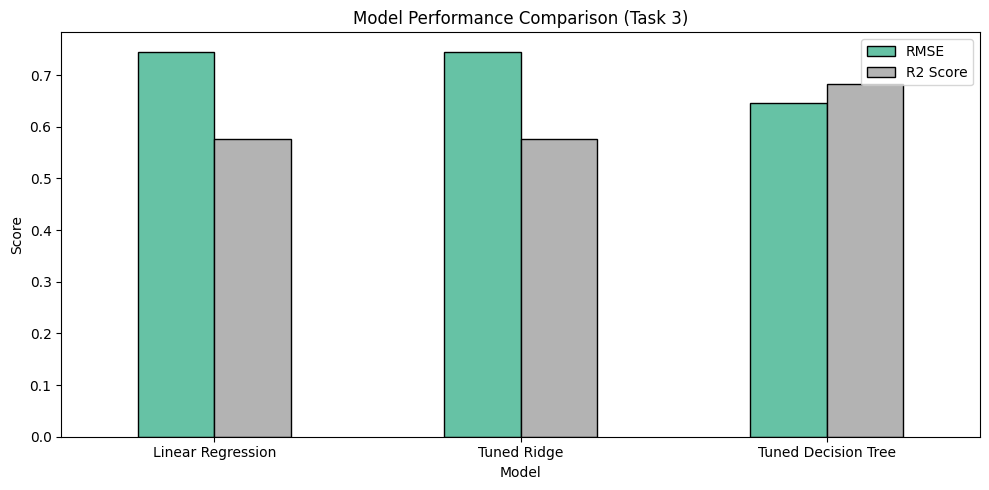

In [14]:
results_df.set_index('Model').plot(kind='bar', figsize=(10, 5),
                                   colormap='Set2', edgecolor='black')
plt.title('Model Performance Comparison (Task 3)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('task3_model_comparison.png')
plt.show()

Best Model: Tuned Decision Tree


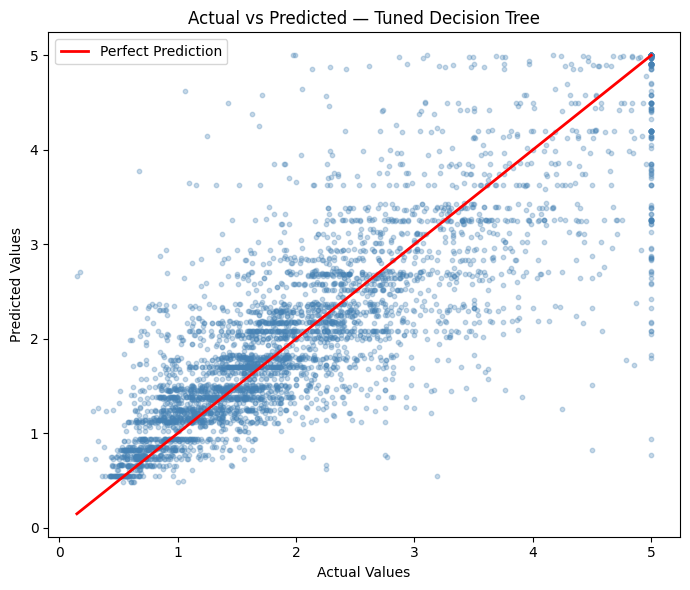

In [15]:
best_model_name = results_df.loc[results_df['RMSE'].idxmin(), 'Model']
print(f"Best Model: {best_model_name}")

if best_model_name == "Tuned Decision Tree":
    final_pred = tree_pred
elif best_model_name == "Tuned Ridge":
    final_pred = ridge_pred
else:
    final_pred = lr_pred

plt.figure(figsize=(7, 6))
plt.scatter(y_test, final_pred, alpha=0.3, s=10, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Actual vs Predicted — {best_model_name}')
plt.legend()
plt.tight_layout()
plt.savefig('task3_actual_vs_predicted.png')
plt.show()

## Step 6: Final Model Selection Justification

In [16]:
best_rmse_val = results_df['RMSE'].min()
best_r2_val   = results_df['R2 Score'].max()

print(f"Selected Model: {best_model_name}")
print(f"RMSE:           {best_rmse_val}")
print(f"R² Score:       {best_r2_val}")
print("""
Justification:
- Overfitting was detected in the untuned Decision Tree (large train/test RMSE gap).
- Cross-validation provided reliable performance estimates across 5 folds.
- GridSearchCV identified the optimal hyperparameters, reducing overfitting.
- The selected model achieves the best balance of low RMSE and high R².
- Cross-validation results are trusted over single split results for generalization.
""")

Selected Model: Tuned Decision Tree
RMSE:           0.6454
R² Score:       0.6821

Justification:
- Overfitting was detected in the untuned Decision Tree (large train/test RMSE gap).
- Cross-validation provided reliable performance estimates across 5 folds.
- GridSearchCV identified the optimal hyperparameters, reducing overfitting.
- The selected model achieves the best balance of low RMSE and high R².
- Cross-validation results are trusted over single split results for generalization.



In [17]:
joblib.dump(best_tree, 'best_model_task3.pkl')
joblib.dump(scaler, 'scaler_task3.pkl')

print("Best model saved as best_model_task3.pkl")
print("Scaler saved as scaler_task3.pkl")

Best model saved as best_model_task3.pkl
Scaler saved as scaler_task3.pkl


## Conclusion
- Overfitting is detected by comparing train vs test RMSE — a large gap signals poor generalization.
- Cross-validation with 5 folds gives a more reliable performance estimate than a single split.
- GridSearchCV automates hyperparameter tuning and finds the optimal configuration.
- The tuned model generalizes better to unseen data compared to the untuned baseline.
- Next steps: Try Random Forest or Gradient Boosting for even better performance.